In [1]:
from rdkit.Chem.Draw import IPythonConsole
import matplotlib.pyplot as plt
from collections import defaultdict
from rdkit.Chem import Draw
from rdkit import Chem
from collections import Counter
from tqdm import tqdm
import pandas as pd
import numpy as np
import os

import bblean
import bblean.plotting as plotting
import bblean.analysis as analysis
import bblean.similarity as iSIM

/home/acomajuncosa/miniconda3/envs/bblean/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
root = "/home/acomajuncosa/Documents_GPU/mtb-targeted-protein-degradation"
PATH_TO_SELECTED_COMPOUNDS = os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "selected_compounds")

In [3]:
def get_splits(path):
    splits = os.listdir(path)
    return [i.replace(".csv", "") for i in sorted(splits)]

def get_pockets():
    df = pd.read_csv("/home/acomajuncosa/Documents_GPU/mtb-targeted-protein-degradation/processed/pocket_detection_data.csv")
    pockets = [f"{i.replace('.pdb', '')}_pocket_{j}" for i, j in zip(df['File name'], df['Pocket number'])]
    return sorted(pockets)

def smiles_grid(smiles, per_row=4, size=(200, 200)):
    mols = [Chem.MolFromSmiles(s) for s in smiles]
    return Draw.MolsToGridImage(mols, molsPerRow=per_row, subImgSize=size, maxMols=10_000)

# Get splits (994)
SPLITS = get_splits(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", 'A_proteins'))

# Get pockets (276)
POCKETS = get_pockets()

In [4]:
df = pd.read_csv(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "filtered_compounds.csv"))

In [5]:
### Sorting df ###

# Counting synthons
counting_synthons = defaultdict(int)
for id_ in tqdm(df['id']):
    if id_.startswith("m_") == False and id_.startswith("s_") == False:
        raise TypeError("ID not starting with m nor s. Please revise")
    synthons = id_.split("____")[1:]
    for synthon in synthons:
        counting_synthons[synthon] += 1

# Adding up synthon counts
COUNTER = []
for id_ in tqdm(df['id']):
    synthons = id_.split("____")[1:]
    synthons = [counting_synthons[i] for i in synthons]
    COUNTER.append(sum(synthons))

# Include info to df
df['synthon_count'] = COUNTER
df = df.sort_values('synthon_count', ascending=False).reset_index(drop=True)
original = df.copy()

100%|██████████| 964993/964993 [-00:01<00:00, -703035.90it/s]


In [6]:
df

,split,index,n_targets,label,smiles,id,rd,MW,logp,QED,nsps_score,synthon_count
0,Enamine_REAL_LeadLike_237,4466028,274.0,A_pockets,O=C(C1=CC=CN1)N1CC=C(C(=O)N2CC3=CC=CC=C3CO2)C1,m_274552____23522170____13185988____13453972,0.887509,323.352,1.87090,0.917419,16.750000,14159
1,Enamine_REAL_LeadLike_237,5379262,275.0,A_pockets,C=C1CON(C(=O)C2=CCN(C(=O)C3=CC4=CC=CC=C4N3)C2)C1,m_274552____23522170____24980052____15976146,0.152695,323.352,1.88010,0.858333,17.666667,14117
2,Enamine_REAL_LeadLike_237,5334325,274.0,A_pockets,O=C(C1=CC2=CC=CC=C2N1)N1CC=C(C(=O)N2CC=CCO2)C1,m_274552____23522170____24976466____15976146,0.799957,323.352,1.88010,0.858333,17.416667,13993
3,Enamine_REAL_LeadLike_123,7375951,273.0,A_pockets,C=C1CON(C(=O)C2=CCN(C(=O)C=CC3=CC=CN3)C2)C1,m_274552____23522170____24980052____13454386,0.701758,299.330,1.12650,0.671853,18.363636,13801
4,Enamine_REAL_LeadLike_123,7362858,272.0,A_pockets,O=C(C=CC1=CC=CN1)N1CC=C(C(=O)N2CC=CCO2)C1,m_274552____23522170____24976466____13454386,0.553013,299.330,1.12650,0.671853,18.090909,13677
...,...,...,...,...,...,...,...,...,...,...,...,...
964988,Enamine_REAL_LeadLike_601,9266610,2.0,B_proteins,CC(C(=O)C1=CC=C2NC(=O)CCC2=C1)N1CCO[C@H](CC2=C...,s_2230____28471852____22390412,0.005089,378.472,3.08600,0.812623,20.892857,2
964989,Enamine_REAL_LeadLike_156,1890389,2.0,B_proteins,CC1=CC(C(=O)NS(=O)(=O)C2=CC(F)=CC(Cl)=C2)=C(Cl...,s_2740____29759458____7101592,0.005131,380.199,3.69872,0.883486,11.347826,2
964990,Enamine_REAL_LeadLike_160,5217229,2.0,B_proteins,CC1=CC=C(NC(=O)C2=CNC3=C2C=CC=C3C)C(C(=O)O)=C1,s_270112____33715112____34099012,0.747790,308.337,3.73524,0.689113,10.695652,2
964991,Enamine_REAL_LeadLike_067,7684210,2.0,B_proteins,COC1=NC2=CC=CC=C2C=C1CSCC1=NC=NN1C,s_62____15747016____6737210,0.622446,300.387,2.80530,0.724987,10.952381,2


In [7]:
MAX_SYNTHON = 3
SYNTHON_COUNTS = defaultdict(int)
KEEP = []

for id_ in tqdm(df['id']):

    if id_.startswith("m_") == False and id_.startswith("s_") == False:
        raise TypeError("ID not starting with m nor s. Please revise")
    
    
    synthons = id_.split("____")[1:]
    keep = True
    tmp_dict = defaultdict(int)

    # tmp dict with synthons
    for synthon in synthons:
        tmp_dict[synthon] += 1

    # check valid compound
    for synthon in synthons:
        if SYNTHON_COUNTS[synthon] + tmp_dict[synthon] <= MAX_SYNTHON:
            pass
        else:
            keep = False
            break

    # add compound if valid
    if keep == True:
        KEEP.append(True)
        for synthon in synthons:
            SYNTHON_COUNTS[synthon] += 1
        
    else:
        KEEP.append(False)
        

df['keep_synthon'] = KEEP
d = Counter(KEEP)
print(round(100 * d[True] / (d[True] + d[False]), 2), "%")

100%|██████████| 964993/964993 [00:01<00:00, 879016.19it/s] 

16.43 %


In [8]:
df = df[df['keep_synthon']].reset_index(drop=True)

In [9]:
df

,split,index,n_targets,label,smiles,id,rd,MW,logp,QED,nsps_score,synthon_count,keep_synthon
0,Enamine_REAL_LeadLike_237,4466028,274.0,A_pockets,O=C(C1=CC=CN1)N1CC=C(C(=O)N2CC3=CC=CC=C3CO2)C1,m_274552____23522170____13185988____13453972,0.887509,323.352,1.87090,0.917419,16.750000,14159,True
1,Enamine_REAL_LeadLike_237,5379262,275.0,A_pockets,C=C1CON(C(=O)C2=CCN(C(=O)C3=CC4=CC=CC=C4N3)C2)C1,m_274552____23522170____24980052____15976146,0.152695,323.352,1.88010,0.858333,17.666667,14117,True
2,Enamine_REAL_LeadLike_237,5334325,274.0,A_pockets,O=C(C1=CC2=CC=CC=C2N1)N1CC=C(C(=O)N2CC=CCO2)C1,m_274552____23522170____24976466____15976146,0.799957,323.352,1.88010,0.858333,17.416667,13993,True
3,Enamine_REAL_LeadLike_315,8096988,273.0,A_pockets,O=C(C1=CC=CN1)N1CC=CC(C(=O)N2CC3=CC=CC=C3CO2)C1,m_274552____23521314____13185988____13453972,0.707047,337.379,2.11690,0.853849,19.600000,13604,True
4,Enamine_REAL_LeadLike_315,8653010,273.0,A_pockets,O=C(C1=CC2=CC=CC=C2N1)N1CC=CC(C(=O)N2CC=CCO2)C1,m_274552____23521314____24976466____15976146,0.018472,337.379,2.12610,0.853936,20.240000,13438,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
158553,Enamine_REAL_LeadLike_601,9266610,2.0,B_proteins,CC(C(=O)C1=CC=C2NC(=O)CCC2=C1)N1CCO[C@H](CC2=C...,s_2230____28471852____22390412,0.005089,378.472,3.08600,0.812623,20.892857,2,True
158554,Enamine_REAL_LeadLike_156,1890389,2.0,B_proteins,CC1=CC(C(=O)NS(=O)(=O)C2=CC(F)=CC(Cl)=C2)=C(Cl...,s_2740____29759458____7101592,0.005131,380.199,3.69872,0.883486,11.347826,2,True
158555,Enamine_REAL_LeadLike_160,5217229,2.0,B_proteins,CC1=CC=C(NC(=O)C2=CNC3=C2C=CC=C3C)C(C(=O)O)=C1,s_270112____33715112____34099012,0.747790,308.337,3.73524,0.689113,10.695652,2,True
158556,Enamine_REAL_LeadLike_067,7684210,2.0,B_proteins,COC1=NC2=CC=CC=C2C=C1CSCC1=NC=NN1C,s_62____15747016____6737210,0.622446,300.387,2.80530,0.724987,10.952381,2,True


In [10]:
SMILES = df['smiles'].tolist()

In [11]:
fps = bblean.fps_from_smiles(SMILES, pack=True, n_features=2048, kind="ecfp6")

In [12]:
fps.shape

(158558, 256)

In [13]:
average_sim = iSIM.jt_isim(fps)
isim_sigma = iSIM.estimate_jt_std(fps)
print(f"Estimated similarity mean and std: {average_sim:.3f}, std: {isim_sigma:.3f}")
optimal_threshold = 0.3

Estimated similarity mean and std: 0.095, std: 0.030


In [14]:
bb_tree = bblean.BitBirch(branching_factor=50, threshold=optimal_threshold, merge_criterion="diameter")
bb_tree.fit(fps)

BitBirch(threshold=0.3, branching_factor=50, merge_criterion='diameter')

In [15]:
clusters = bb_tree.get_cluster_mol_ids()
print(f"Number of clusters: {len(clusters)}")
print("Number of singletons", sum(1 for c in clusters if len(c) == 1))

Number of clusters: 120385
Number of singletons 99721


In [16]:
bb_tree.recluster_inplace(iterations=5, extra_threshold=isim_sigma, shuffle=False, verbose=True)

Current number of clusters: 120385
Current number of singletons: 99721
Current number of clusters: 108759
Current number of singletons: 82084
Current number of clusters: 103508
Current number of singletons: 73941
Current number of clusters: 101062
Current number of singletons: 69897
Current number of clusters: 99825
Current number of singletons: 67779
Final number of clusters: 99139
Final number of singletons: 66562


BitBirch(threshold=0.45148707465021004, branching_factor=50, merge_criterion='diameter')

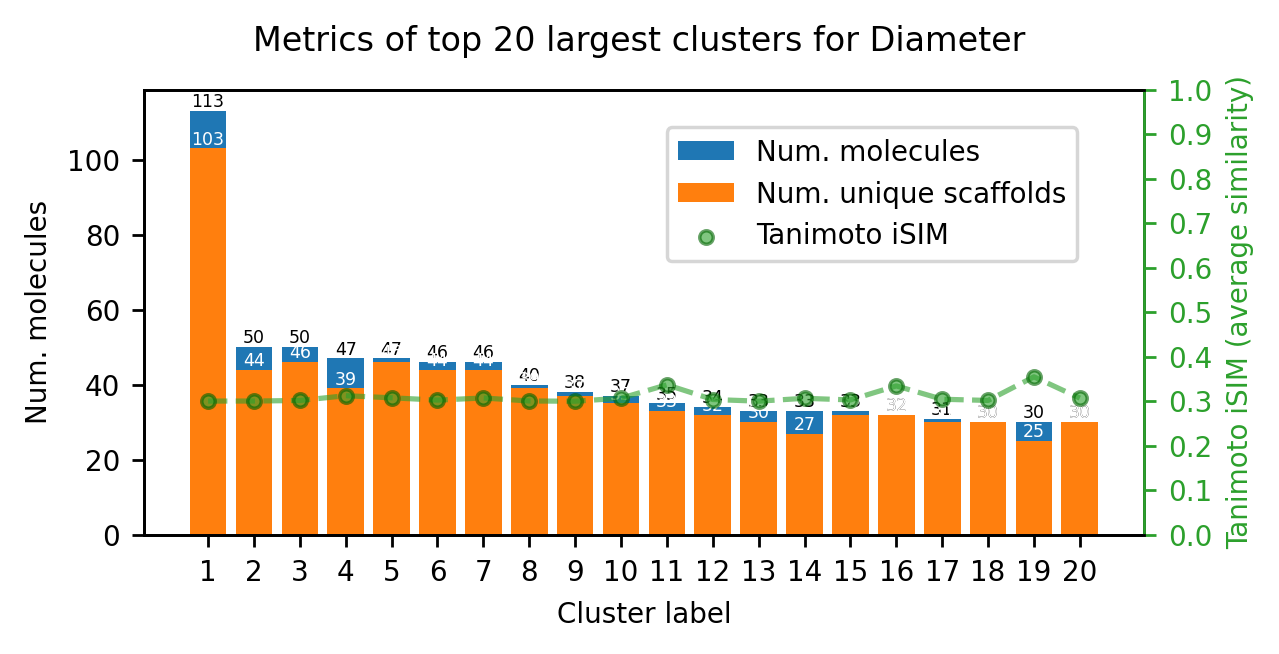

In [17]:
# First we run a cluster analysis on the resulting ids
clusters = bb_tree.get_cluster_mol_ids()
ca = analysis.cluster_analysis(clusters, fps, SMILES)

# Afterwards we can use the utility functions on the bblean.plotting module
plotting.summary_plot(ca, title="Diameter")
plt.show()

In [18]:
# Total clusters
print("Number of clusters: ", len(clusters))

# Clusters with more than 10 molecules
large_clusters = [c for c in clusters if len(c) > 10]
print("Number of clusters with more than 10 molecules: ", len(large_clusters))

Number of clusters:  99139
Number of clusters with more than 10 molecules:  414


In [19]:
ind_to_cluster_label = dict()
for cluster_number, inds in enumerate(clusters):
    for ind in inds:
        ind_to_cluster_label[ind] = cluster_number

df["cluster_number"] = [ind_to_cluster_label[i] for i in range(len(df))]

In [20]:
df = df.drop_duplicates(subset=['cluster_number'], keep='first').reset_index(drop=True)

In [21]:
Counter(df['label'])

Counter({'B_proteins': 43051,
         'B_pockets': 27314,
         'A_proteins': 23845,
         'A_pockets': 4929})

In [22]:
df.to_csv(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "clustered_compounds.csv"), index=False)

In [23]:
len(df)

99139

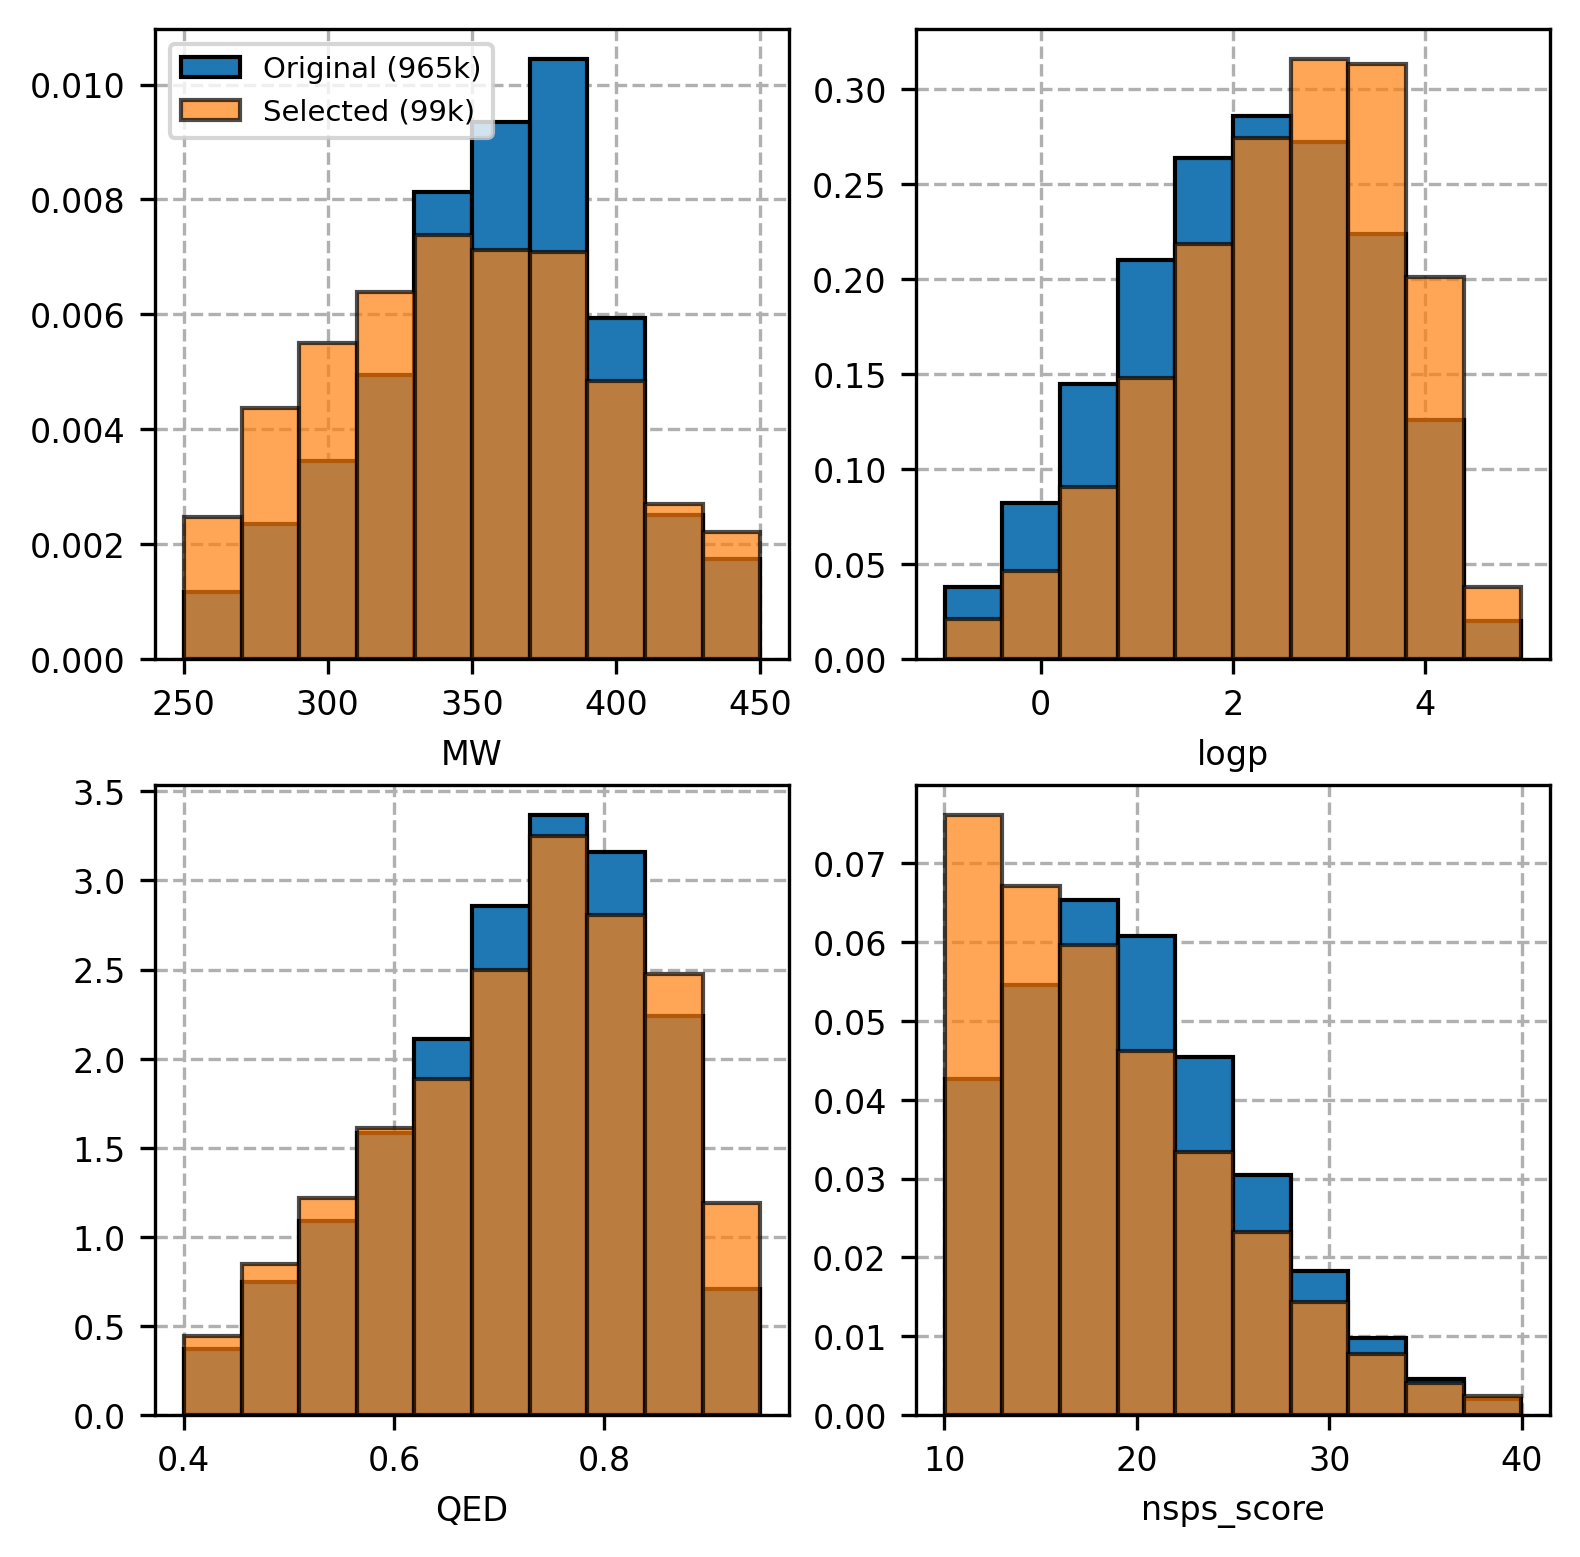

In [24]:
fig, ax = plt.subplots(2, 2, figsize=(6, 6), dpi=300)

lab = 'MW'
c1, c2 = 0, 0
bins = [i for i in range(200, 500, 10)]
ax[c1][c2].hist(original[lab], ec='k', density=True, zorder=2, label="Original (965k)")
ax[c1][c2].hist(df[lab], ec='k', density=True, alpha=0.7, zorder=2, label='Selected (99k)')
ax[c1][c2].grid(linestyle='--', zorder=-2)
ax[c1][c2].set_xlabel(lab)
ax[c1][c2].legend(loc='upper left', prop={'size': 7})

lab = 'logp'
c1, c2 = 0, 1
bins = [i for i in np.arange(-1.35, 5.35, 0.25)]
ax[c1][c2].hist(original[lab], ec='k', density=True, zorder=2)
ax[c1][c2].hist(df[lab], ec='k', density=True, alpha=0.7, zorder=2)
ax[c1][c2].grid(linestyle='--', zorder=-2)
ax[c1][c2].set_xlabel(lab)

lab = 'QED'
c1, c2 = 1, 0
bins = [i for i in np.arange(-0.1, 1.1, 0.05)]
ax[c1][c2].hist(original[lab], ec='k', density=True, zorder=2)
ax[c1][c2].hist(df[lab], ec='k', density=True, alpha=0.7, zorder=2)
ax[c1][c2].grid(linestyle='--', zorder=-2)
ax[c1][c2].set_xlabel(lab)

lab = 'nsps_score'
c1, c2 = 1, 1
bins = [i for i in np.arange(0, 50, 5)]
ax[c1][c2].hist(original[lab], ec='k', density=True, zorder=2)
ax[c1][c2].hist(df[lab], ec='k', density=True, alpha=0.7, zorder=2)
ax[c1][c2].grid(linestyle='--', zorder=-2)
ax[c1][c2].set_xlabel(lab)

plt.show()

In [25]:
df

,split,index,n_targets,label,smiles,id,rd,MW,logp,QED,nsps_score,synthon_count,keep_synthon,cluster_number
0,Enamine_REAL_LeadLike_237,4466028,274.0,A_pockets,O=C(C1=CC=CN1)N1CC=C(C(=O)N2CC3=CC=CC=C3CO2)C1,m_274552____23522170____13185988____13453972,0.887509,323.352,1.87090,0.917419,16.750000,14159,True,879
1,Enamine_REAL_NaturalProducts_026,2928505,276.0,A_pockets,O=C(C1=CCC2CCC1N2C(=O)C=CC1=CC=CN1)N1CC=CCO1,m_274552____23520122____24976466____13454386,0.736887,339.395,2.04760,0.676979,25.520000,12627,True,25034
2,Enamine_REAL_NaturalProducts_021,2676255,276.0,A_pockets,O=C1C=CC=C(C(=O)N2CC=CC2C(=O)N2CC3CC=CC2C3)N1,m_274552____23521810____24977990____13454236,0.847292,325.368,0.93250,0.822341,27.750000,10974,True,96467
3,Enamine_REAL_LeadLike_084,9414836,275.0,A_pockets,O=C(C1C=CCN1C(=O)C=CC1=CC=CN1)N1CC=CC1,m_274552____23521810____13184720____13454386,0.975398,283.331,1.19330,0.669052,20.857143,10300,True,5953
4,Enamine_REAL_LeadLike_236,1127300,275.0,A_pockets,C#CC1=C(C(=O)N2CC=CC2C(=O)NC2=CN=CNC2=O)NN=C1,m_274552____23521810____25005974____25051568,0.314589,324.300,-0.50640,0.518231,15.958333,9793,True,4862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99134,Enamine_REAL_LeadLike_057,9108131,50.0,B_pockets,CC1=CC=C2C=CC=CC2=C1C=CC(=O)C1=NC=CN1C,s_6____4929988____30641444,0.549776,276.339,3.77782,0.538784,11.333333,2,True,47655
99135,Enamine_REAL_LeadLike_601,9266610,2.0,B_proteins,CC(C(=O)C1=CC=C2NC(=O)CCC2=C1)N1CCO[C@H](CC2=C...,s_2230____28471852____22390412,0.005089,378.472,3.08600,0.812623,20.892857,2,True,96350
99136,Enamine_REAL_LeadLike_156,1890389,2.0,B_proteins,CC1=CC(C(=O)NS(=O)(=O)C2=CC(F)=CC(Cl)=C2)=C(Cl...,s_2740____29759458____7101592,0.005131,380.199,3.69872,0.883486,11.347826,2,True,66379
99137,Enamine_REAL_LeadLike_160,5217229,2.0,B_proteins,CC1=CC=C(NC(=O)C2=CNC3=C2C=CC=C3C)C(C(=O)O)=C1,s_270112____33715112____34099012,0.747790,308.337,3.73524,0.689113,10.695652,2,True,52000
